# 032 — Evaluation: EfficientNet (deterministic + NLL, Round 2 recipe)

Quantitative comparison of the four EfficientNet-encoder checkpoints on the held-out test set: `efficientnet_unet` / `efficientnet_unet_ft` (deterministic, `combined_loss` — `fixing.md` #9) and `efficientnet_unet_nll` / `efficientnet_unet_nll_ft` (heteroscedastic, unified `laplace_nll` — `fixing.md` #10), all trained by `022_training_efficientnet.ipynb`'s two-phase (frozen-then-fine-tuned) procedure (`fixing.md` #6). Replaces this notebook's pre-Round-2 content, which evaluated only `efficientnet_unet_nll` under **both** `gaussian_nll`/`beta_nll` variants — that comparison axis is gone now that Round 2 collapsed it, the same way `031_evaluation_nll.ipynb` already did for the other three NLL architectures. Same block layout as `030_evaluation.ipynb` — see its title cell for the full table of companion notebooks.

Deterministic metrics (`mae`/`ssim`/`psnr`) and NLL metrics (`mu_mae`/`mu_ssim`/`mu_psnr`, computed from the `mu` channel only via `scripts.metrics.Mu*Metric`) are reported in separate tables/charts below — `loss` differs in scale and meaning between the two families (`combined_loss` vs. `laplace_nll_loss`), so it is never compared across them.

Make the project root importable so `scripts.*` resolves regardless of
the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check.

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build the test dataset

Artwork-and-mockups split, same as the notebook that trained these
checkpoints — required so the reported test metrics are on data none of
them saw during training or validation. One dataset serves both families:
`build_dataset` always yields `(rgb, ir)` pairs, and the deterministic vs.
NLL models differ only in how many output channels they predict from it.

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
print(f"Test pairs: {len(test_pairs)} | Test batches: {len(test_ds)}")

Test pairs: 135 | Test batches: 17


2026-08-26 11:42:19.722938: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 11:42:19.722958: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 11:42:19.722965: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 11:42:19.722979: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 11:42:19.722989: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Evaluate the deterministic checkpoints

Checkpoints load from `models/deterministic/efficientnet_unet/best_model.keras`
and `models/deterministic/efficientnet_unet_ft/best_model.keras`
(`022_training_efficientnet.ipynb`). A missing checkpoint is skipped, not
treated as an error, so this notebook still runs before phase 2 has been
trained.

In [4]:
DET_ARCHS = ["efficientnet_unet", "efficientnet_unet_ft"]
DET_MODEL_DIR = settings.MODELS_DIR / "deterministic"
det_results: dict = {}

for arch in DET_ARCHS:
    try:
        model = load_model(
            arch,
            model_dir=DET_MODEL_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"Evaluating {arch}...")
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    det_results[arch] = metrics
    print(f"  {arch}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")

Evaluating efficientnet_unet...


2026-08-26 11:42:21.888789: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  efficientnet_unet: {'loss': '0.3323', 'mae': '0.1558', 'psnr': '16.3958', 'ssim': '0.5480'}
Evaluating efficientnet_unet_ft...
  efficientnet_unet_ft: {'loss': '0.3415', 'mae': '0.1562', 'psnr': '16.2867', 'ssim': '0.5468'}


## 3. Evaluate the NLL checkpoints

Checkpoints load from `models/nll/efficientnet_unet_nll/best_model.keras`
and `models/nll/efficientnet_unet_nll_ft/best_model.keras`, both trained
with the unified `laplace_nll` loss (`fixing.md` #10) — no more
`gaussian_nll`/`beta_nll` split to evaluate separately.

In [5]:
NLL_ARCHS = ["efficientnet_unet_nll", "efficientnet_unet_nll_ft"]
NLL_MODEL_DIR = settings.MODELS_DIR / "nll"
nll_results: dict = {}

for arch in NLL_ARCHS:
    try:
        model = load_model_nll(
            arch,
            model_dir=NLL_MODEL_DIR,
            loss_name="laplace_nll",
            beta=settings.NLL_BETA,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"Evaluating {arch}...")
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    nll_results[arch] = metrics
    print(f"  {arch}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")

Evaluating efficientnet_unet_nll...
  efficientnet_unet_nll: {'loss': '-0.4472', 'mae': '0.1099', 'psnr': '18.0376', 'ssim': '0.4225'}
Evaluating efficientnet_unet_nll_ft...
  efficientnet_unet_nll_ft: {'loss': '-0.4278', 'mae': '0.1181', 'psnr': '17.6698', 'ssim': '0.3940'}


## 4. Comparison tables

In [8]:
def print_table(results: dict, label: str) -> None:
    if not results:
        print(f"[no results for {label}]")
        return
    col_w = 25
    headers = [label] + list(next(iter(results.values())).keys())
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for name, metrics in results.items():
        row = [name] + [f"{v:.4f}" for v in metrics.values()]
        print("".join(c.ljust(col_w) for c in row))


print_table(det_results, "architecture")
print()
print_table(nll_results, "architecture")

architecture             loss                     mae                      psnr                     ssim                     
-----------------------------------------------------------------------------------------------------------------------------
efficientnet_unet        0.3323                   0.1558                   16.3958                  0.5480                   
efficientnet_unet_ft     0.3415                   0.1562                   16.2867                  0.5468                   

architecture             loss                     mae                      psnr                     ssim                     
-----------------------------------------------------------------------------------------------------------------------------
efficientnet_unet_nll    -0.4472                  0.1099                   18.0376                  0.4225                   
efficientnet_unet_nll_ft -0.4278                  0.1181                   17.6698                  0.3940           

## 5. Bar chart comparisons

/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

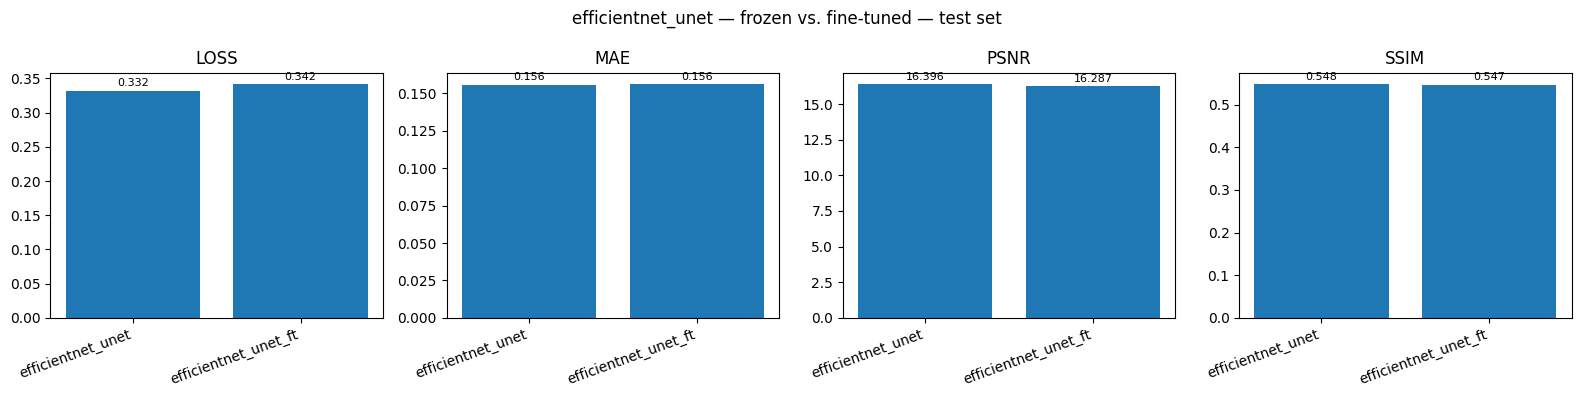

/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4815/2246060528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

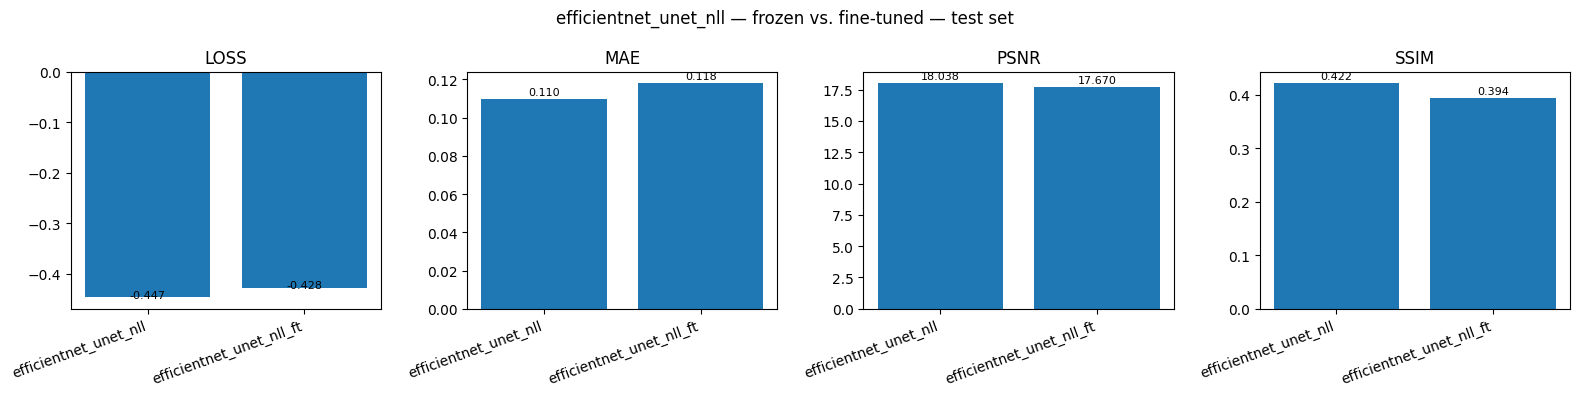

In [7]:
def bar_chart(results: dict, title: str) -> None:
    if not results:
        return
    metric_keys = list(next(iter(results.values())).keys())
    n = len(metric_keys)
    names = list(results.keys())
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle(title)
    for ax, key in zip(axes, metric_keys):
        vals = [results[m][key] for m in names]
        bars = ax.bar(names, vals)
        ax.set_title(key.upper())
        ax.set_xticklabels(names, rotation=20, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()


bar_chart(det_results, "efficientnet_unet — frozen vs. fine-tuned — test set")
bar_chart(nll_results, "efficientnet_unet_nll — frozen vs. fine-tuned — test set")